# 01 - Phân tích dataset DOE multi-batch (Phase 2-3)

**Nguồn dữ liệu:** `outputs/phase3/manifest_quality.csv` (fallback `manifest.csv`) - 7.920 mẫu SIMP từ các batch DOE trong `outputs/multi_batch/`, đọc qua `utils.load_all_samples()`. **Không** phải 550 mẫu LHS screening của Phase 1 (`outputs/pipeline/phase1/`) - 3 notebook cũ đặt tên "Phase 1" nhưng thực tế luôn đọc manifest này.

**Mục tiêu:** dataset có sạch không, seed/tham số nào cho ν12 âm mạnh nhất, thiết kế tốt nhất trông như thế nào.

Gộp từ 3 notebook cũ (01 QC, 02 hiệu năng & độ nhạy, 03 soi chi tiết) ngày 2026-10-08. Đã bỏ: file trung gian `cleaned_dataset.parquet` (giờ dùng thẳng DataFrame trong bộ nhớ) và phần "đề xuất tham số Phase 2" (`next_sweep_config.json`) - Phase 2 đã chạy xong với tham số riêng trong `pipeline/phase2_multi_batch/params.py`, đề xuất cũ (`mu=0.2`) không còn đúng với mặc định hiện hành.

**Giới hạn đã biết:**
- Manifest đã qua lọc Phase 3 nên §4-5 (void, miền hợp lệ ν12) gần như luôn sạch (void 3/7920, ν12 hợp lệ 100%) - giữ lại làm kiểm tra sanity.
- Manifest không có cột `rotation_deg`/`mu` nên hai cột này là hằng số: §14 chỉ in số đếm, và chúng ra NaN trong heatmap Spearman §8.
- §12-13 cần ảnh và `iteration_data.csv` trong `outputs/multi_batch/*/*/sample_*/` (bị gitignore) - chỉ chạy đủ trên máy có dữ liệu gốc.

### Nội dung
- **A. Chất lượng dữ liệu** (§1-5): gom mẫu, hội tụ, hình học rời rạc, void collapse, miền hợp lệ của ν12
- **B. Hiệu năng & độ nhạy** (§6-11): lọc mẫu, so sánh seed, tương quan Spearman, VolFrac vs ν12, ngưỡng rmin, ảnh hưởng tham số
- **C. Soi chi tiết** (§12-14): top-10 thiết kế, lịch sử hội tụ, ảnh hưởng rotation


In [1]:
# ── Setup & Imports ──
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

# Chạy từ gốc repo: thêm notebooks/ vào path để import utils dùng chung
sys.path.insert(0, str(Path.cwd() / "notebooks"))
import utils

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.max_open_warning": 0})

print(f"Manifest dir: {utils.PHASE3_DIR}")


Manifest dir: /home/tbm/Documents/Input_SIMP_Analyst/outputs/phase3


---
## 1. Gom dữ liệu

Đọc manifest Phase 3 (`manifest_quality.csv`) → 1 dòng/mẫu: ν12/ν21, VF, objective, số vòng lặp thật, cờ hội tụ/rời rạc/void, tham số SIMP.


In [2]:
# ── Load all samples into a master DataFrame ──
df_raw = utils.load_all_samples()
print(f"Total samples loaded: {len(df_raw)}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Total samples loaded: 7920
Columns: ['batch', 'seed', 'sample_id', 'image_path', 'final_nu12', 'final_nu21', 'final_VF', 'final_obj', 'converged', 'volfrac', 'penal', 'rmin', 'move', 'void_size_frac', 'n_components', 'is_connected', 'degenerate', 'solid_frac', 'n_iters', 'max_iter', 'hit_cap', 'osc_score', 'osc_unstable', 'sample_path', 'n_iter', 'converged_flag', 'disconnected_flag', 'void_flag', 'nu_valid_flag', 'rotation_deg', 'mu']


,batch,seed,sample_id,image_path,final_nu12,final_nu21,final_VF,final_obj,converged,volfrac,...,osc_score,osc_unstable,sample_path,n_iter,converged_flag,disconnected_flag,void_flag,nu_valid_flag,rotation_deg,mu
0,1,circle,0,outputs/multi_batch/batch_1/circle/sample_0000...,-0.398465,-0.403463,0.613837,0.907847,True,0.613838,...,0.021439,False,outputs/multi_batch/batch_1/circle/sample_0000,150,False,False,False,True,0.0,0.0
1,1,circle,1,outputs/multi_batch/batch_1/circle/sample_0001...,0.000032,0.000032,0.456511,0.841383,True,0.456512,...,0.187295,True,outputs/multi_batch/batch_1/circle/sample_0001,150,False,False,False,True,0.0,0.0
2,1,circle,2,outputs/multi_batch/batch_1/circle/sample_0002...,-0.083166,-0.087375,0.547052,0.844156,True,0.547052,...,0.084774,False,outputs/multi_batch/batch_1/circle/sample_0002,150,False,False,False,True,0.0,0.0
3,1,circle,3,outputs/multi_batch/batch_1/circle/sample_0003...,-0.292183,-0.292183,0.639512,0.564407,True,0.639513,...,0.016900,False,outputs/multi_batch/batch_1/circle/sample_0003,150,False,False,False,True,0.0,0.0
4,1,circle,4,outputs/multi_batch/batch_1/circle/sample_0004...,-0.128070,-0.128070,0.576097,0.901782,True,0.671054,...,0.041690,False,outputs/multi_batch/batch_1/circle/sample_0004,150,False,False,False,True,0.0,0.0


In [3]:
# ── Summary by seed ──
summary = df_raw.groupby("seed").agg(
    n_samples=("final_nu12", "count"),
    nu12_mean=("final_nu12", "mean"),
    nu12_median=("final_nu12", "median"),
    nu12_std=("final_nu12", "std"),
    VF_mean=("final_VF", "mean"),
    converged=("converged_flag", "sum"),
    void=("void_flag", "sum"),
).round(4)
summary

,n_samples,nu12_mean,nu12_median,nu12_std,VF_mean,converged,void
seed,,,,,,,
circle,720,-0.2775,-0.2924,0.1538,0.5534,53,0
circle_half_quarter,720,-0.1117,-0.1517,0.1773,0.5016,47,0
cross_rectangular,720,-0.2746,-0.2949,0.1559,0.5523,57,1
four_circle,720,-0.2644,-0.3080,0.1641,0.5372,120,1
grid_circular_voids,720,-0.3654,-0.3752,0.0828,0.5567,229,0
hexagonal,720,-0.3488,-0.3575,0.1395,0.5422,195,0
hourglass,720,-0.6246,-0.6280,0.0430,0.5424,438,0
nine_circle,720,-0.3638,-0.3751,0.0894,0.5571,233,0
reentrant_bowtie,720,-0.1722,-0.1015,0.1634,0.5377,405,0


---
## 2. Đánh giá Hội tụ (Convergence)

Kiểm tra `n_iter` có đạt `max_iter` (150) hay dừng sớm do `change/obj` dưới ngưỡng tolerance không.

> **Lưu ý (audit 2026-07-24, xem `EXPERIMENT_LOG.md`):** cột `converged` gốc trong `manifest.csv` (`simp/core/convergence.py::ConvergenceChecker.should_stop()`) trả về `True` **cả khi chỉ đơn giản chạm `max_iter`**, không chỉ khi tolerance thực sự thoả mãn - `converged=True` KHÔNG đồng nghĩa "đã hội tụ theo nghĩa tolerance". `converged_flag` ở đây (từ `manifest_quality.csv` nếu đã chạy `analysis/scripts/audit_convergence_and_geometry.py`) tách riêng 2 trường hợp bằng `n_iters < max_iter`. Trên toàn bộ 7.920 mẫu: chỉ **23,7%** hội tụ thật vì tolerance, **76,3%** chạm trần 150 vòng lặp.

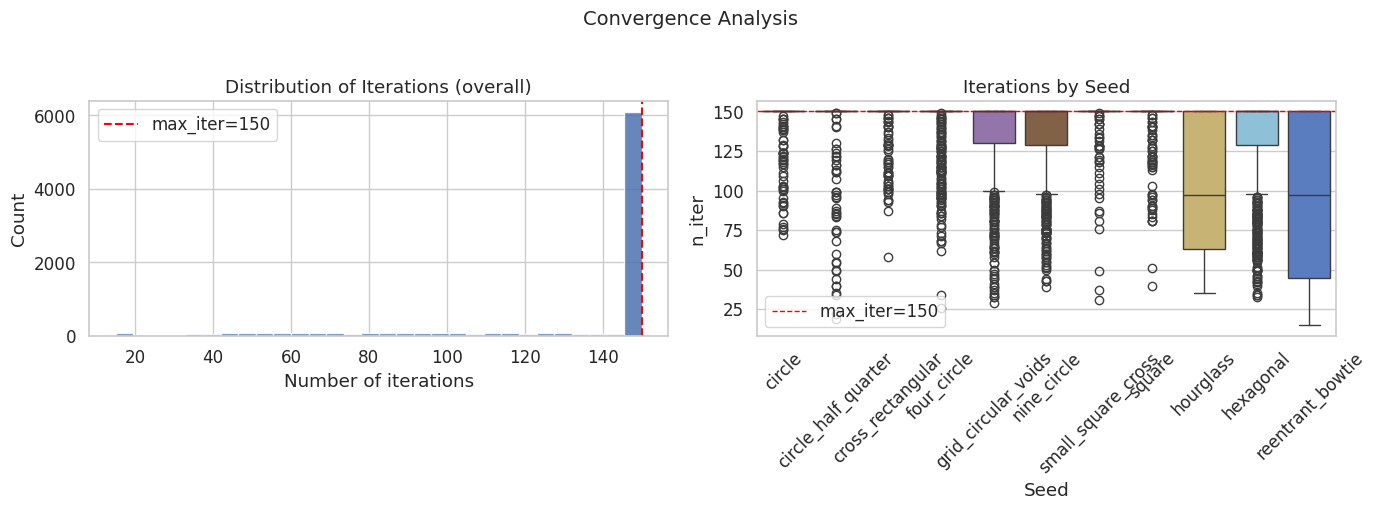

Converged early (n_iter < 150): 23.7% of samples


In [4]:
# ── Distribution of n_iter ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overall
ax = axes[0]
ax.hist(df_raw["n_iter"].dropna(), bins=30, color="#4c72b0", edgecolor="white", alpha=0.85)
ax.axvline(utils.MAX_ITER, color="red", ls="--", lw=1.5, label=f"max_iter={utils.MAX_ITER}")
ax.set_xlabel("Number of iterations")
ax.set_ylabel("Count")
ax.set_title("Distribution of Iterations (overall)")
ax.legend()

# Boxplot by seed
ax = axes[1]
df_plot = df_raw.dropna(subset=["n_iter"])
sns.boxplot(data=df_plot, x="seed", y="n_iter", ax=ax, palette="muted")
ax.axhline(utils.MAX_ITER, color="red", ls="--", lw=1, label=f"max_iter={utils.MAX_ITER}")
ax.set_xlabel("Seed")
ax.set_ylabel("n_iter")
ax.set_title("Iterations by Seed")
ax.tick_params(axis="x", rotation=45)
ax.legend()

fig.suptitle("Convergence Analysis", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Stats
converged_rate = df_raw["converged_flag"].mean() * 100
print(f"Converged early (n_iter < {utils.MAX_ITER}): {converged_rate:.1f}% of samples")

In [5]:
# ── Convergence per seed (detailed table) ──
conv_summary = df_raw.groupby("seed").agg(
    total=("converged_flag", "count"),
    converged=("converged_flag", "sum"),
    not_converged=("converged_flag", lambda x: (~x.astype(bool)).sum()),
    mean_n_iter=("n_iter", "mean"),
    min_n_iter=("n_iter", "min"),
    max_n_iter=("n_iter", "max"),
).round(1)
conv_summary["converge_rate(%)"] = (conv_summary["converged"] / conv_summary["total"] * 100).round(1)
conv_summary

,total,converged,not_converged,mean_n_iter,min_n_iter,max_n_iter,converge_rate(%)
seed,,,,,,,
circle,720,53,667,147.5,72,150,7.4
circle_half_quarter,720,47,673,146.2,19,150,6.5
cross_rectangular,720,57,663,147.5,58,150,7.9
four_circle,720,120,600,143.6,26,150,16.7
grid_circular_voids,720,229,491,135.2,29,150,31.8
hexagonal,720,195,525,132.0,33,150,27.1
hourglass,720,438,282,103.4,35,150,60.8
nine_circle,720,233,487,135.1,39,150,32.4
reentrant_bowtie,720,405,315,95.4,15,150,56.2


---
## 3. Kiểm tra hình học rời rạc (Disconnected Geometry)

Đúng ν₁₂/ν₂₁ qua FE (PBC chỉ ràng buộc trường chuyển vị lúc giải, không ràng buộc vật liệu phải liền khối) không đồng nghĩa cấu trúc **liền khối/in được** - cần quét riêng bằng connected-component labeling (`pipeline/phase5_cvae/manufacturability.py::check_connectivity`, 8-connectivity) trên đúng ảnh 64×64 mà Phase 3 dùng train (BOX-resize, khớp `build_npz.py::load_and_resize`).

Cần chạy trước: `python3 analysis/scripts/audit_convergence_and_geometry.py` (tạo `outputs/phase3/manifest_quality.csv` - nếu chưa chạy, cell dưới sẽ báo thiếu cột và bỏ qua phần này).

Rời rạc (n_components > 1) toàn dataset: 23.9% (1891/7920 mẫu)


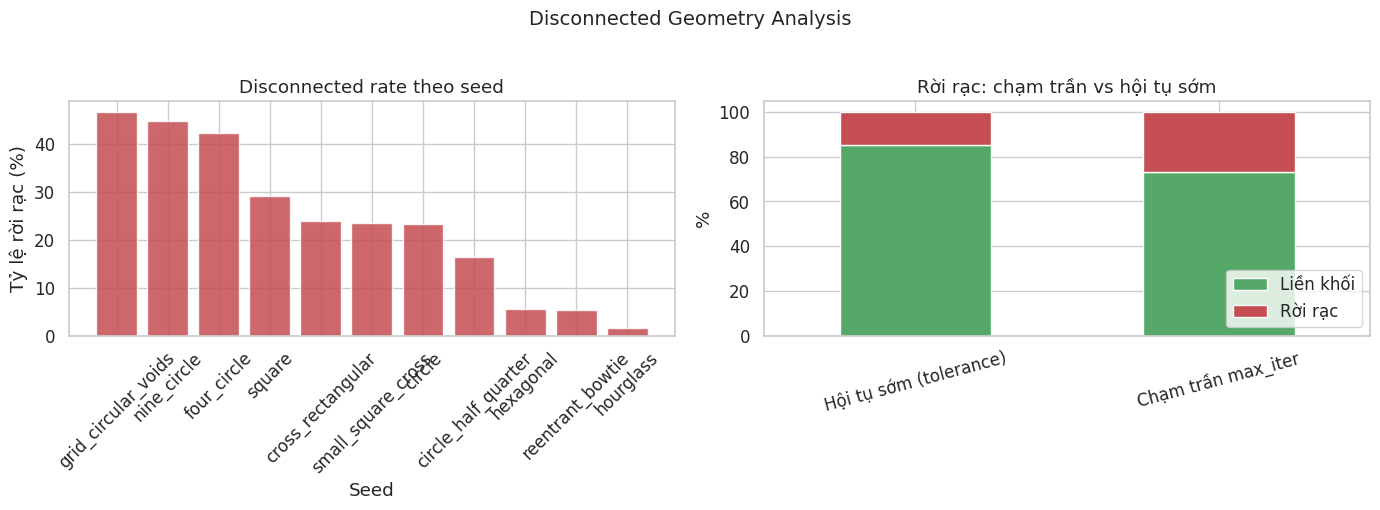


Theo seed:


seed
grid_circular_voids    46.7
nine_circle            44.7
four_circle            42.2
square                 29.2
cross_rectangular      24.0
small_square_cross     23.6
circle                 23.3
circle_half_quarter    16.5
hexagonal               5.6
reentrant_bowtie        5.3
hourglass               1.5
Name: disconnected_flag, dtype: float64

In [6]:
# ── Disconnected geometry ──
if "disconnected_flag" in df_raw.columns:
    disc_rate = df_raw["disconnected_flag"].mean() * 100
    print(f"Rời rạc (n_components > 1) toàn dataset: {disc_rate:.1f}% "
          f"({int(df_raw['disconnected_flag'].sum())}/{len(df_raw)} mẫu)")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar theo seed
    ax = axes[0]
    disc_by_seed = df_raw.groupby("seed")["disconnected_flag"].mean().sort_values(ascending=False) * 100
    ax.bar(disc_by_seed.index, disc_by_seed.values, color="#c44e52", alpha=0.85)
    ax.set_xlabel("Seed")
    ax.set_ylabel("Tỷ lệ rời rạc (%)")
    ax.set_title("Disconnected rate theo seed")
    ax.tick_params(axis="x", rotation=45)

    # Cross-tab: chạm trần (hit_cap, tức converged_flag=False) vs rời rạc
    ax = axes[1]
    cross = pd.crosstab(~df_raw["converged_flag"], df_raw["disconnected_flag"], normalize="index") * 100
    cross.index = ["Hội tụ sớm (tolerance)", "Chạm trần max_iter"]
    cross.columns = ["Liền khối", "Rời rạc"]
    cross.plot(kind="bar", stacked=True, ax=ax, color=["#55a868", "#c44e52"])
    ax.set_ylabel("%")
    ax.set_title("Rời rạc: chạm trần vs hội tụ sớm")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(loc="lower right")

    fig.suptitle("Disconnected Geometry Analysis", fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()

    print("\nTheo seed:")
    display(disc_by_seed.round(1))
else:
    print("Chưa có cột 'disconnected_flag' - chạy "
          "'python3 analysis/scripts/audit_convergence_and_geometry.py' trước "
          "để tạo outputs/phase3/manifest_quality.csv, rồi load lại notebook.")
    disc_rate = float("nan")

---
## 4. Phát hiện Void Collapse

Nếu `Volume_Fraction` cuối cùng < 0.01 → đánh dấu là VOID (bỏ qua).

In [7]:
# ── Void ratio ──
void_counts = df_raw.groupby("seed")["void_flag"].agg(["count", "sum"])
void_counts.columns = ["total", "void"]
void_counts["void_rate(%)"] = (void_counts["void"] / void_counts["total"] * 100).round(1)
void_counts

print(f"\nOverall void rate: {df_raw['void_flag'].mean() * 100:.1f}%")
print(f"Samples classified as VOID: {df_raw['void_flag'].sum()}")


Overall void rate: 0.0%
Samples classified as VOID: 3


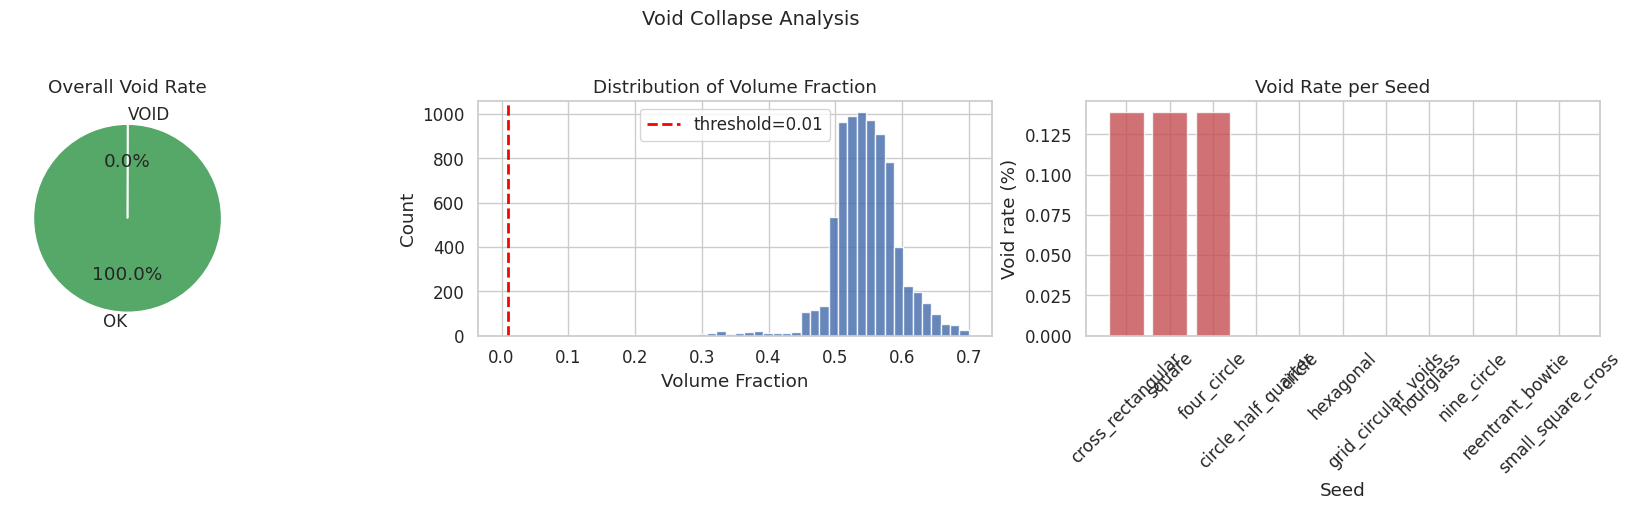

In [8]:
# ── Pie chart: void vs OK ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall
labels = ["OK", "VOID"]
sizes = [
    (~df_raw["void_flag"]).sum(),
    df_raw["void_flag"].sum(),
]
colors = ["#55a868", "#c44e52"]
axes[0].pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
axes[0].set_title("Overall Void Rate")

# Volume_Fraction histogram
ax = axes[1]
ax.hist(df_raw["final_VF"].dropna(), bins=50, color="#4c72b0", edgecolor="white", alpha=0.85)
ax.axvline(utils.VOID_THRESHOLD, color="red", ls="--", lw=2, label=f"threshold={utils.VOID_THRESHOLD}")
ax.set_xlabel("Volume Fraction")
ax.set_ylabel("Count")
ax.set_title("Distribution of Volume Fraction")
ax.legend()

# Void rate per seed (bar)
ax = axes[2]
void_pct = (void_counts["void"] / void_counts["total"] * 100).sort_values(ascending=False)
ax.bar(void_pct.index, void_pct.values, color="#c44e52", alpha=0.8)
ax.set_xlabel("Seed")
ax.set_ylabel("Void rate (%)")
ax.set_title("Void Rate per Seed")
ax.tick_params(axis="x", rotation=45)

fig.suptitle("Void Collapse Analysis", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 5. Kiểm tra tính hợp lý của nu12

Đảm bảo `Poisson_v12` nằm trong khoảng vật lý (-1, 0.5).

In [9]:
# ── nu12 validity ──
total = len(df_raw)
valid = df_raw["nu_valid_flag"].sum()
invalid = total - valid
print(f"Total samples: {total}")
print(f"nu12 valid (-1 < nu < 0.5): {valid} ({valid/total*100:.1f}%)")
print(f"nu12 invalid (out-of-range or NaN): {invalid} ({invalid/total*100:.1f}%)")

# Show invalid details
df_invalid = df_raw[~df_raw["nu_valid_flag"]].copy()
print(f"\n--- Invalid samples (first 10) ---")
if len(df_invalid) > 0:
    display(df_invalid[["seed", "sample_id", "final_nu12", "final_nu21", "void_flag"]].head(10))

Total samples: 7920
nu12 valid (-1 < nu < 0.5): 7920 (100.0%)
nu12 invalid (out-of-range or NaN): 0 (0.0%)

--- Invalid samples (first 10) ---


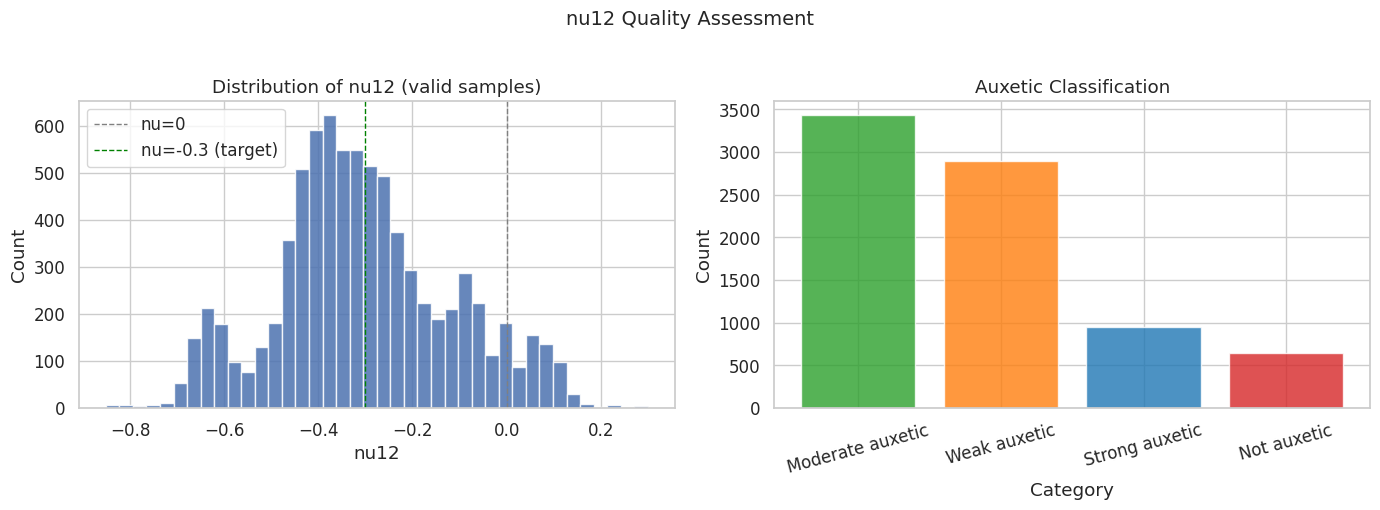


Classification breakdown:
auxetic_class
Moderate auxetic    3430
Weak auxetic        2893
Strong auxetic       956
Not auxetic          641
Name: count, dtype: int64


In [10]:
# ── Histogram of nu12 (valid only) ──
df_valid = df_raw[df_raw["nu_valid_flag"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df_valid["final_nu12"].dropna(), bins=40, color="#4c72b0", edgecolor="white", alpha=0.85)
ax.axvline(0, color="gray", ls="--", lw=1, label="nu=0")
ax.axvline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3 (target)")
ax.set_xlabel("nu12")
ax.set_ylabel("Count")
ax.set_title("Distribution of nu12 (valid samples)")
ax.legend()

ax = axes[1]
df_valid["auxetic_class"] = df_valid["final_nu12"].apply(utils.classify_auxetic_quality)
class_counts = df_valid["auxetic_class"].value_counts()
colors_class = ["#2ca02c", "#ff7f0e", "#1f77b4", "#d62728"]
ax.bar(class_counts.index, class_counts.values, color=colors_class[:len(class_counts)], alpha=0.8)
ax.set_xlabel("Category")
ax.set_ylabel("Count")
ax.set_title("Auxetic Classification")
ax.tick_params(axis="x", rotation=15)

fig.suptitle("nu12 Quality Assessment", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

print("\nClassification breakdown:")
print(class_counts)

---
## 6. Lọc mẫu cho phân tích hiệu năng


In [11]:
# ── Chuyển sang phần B/C: chỉ giữ mẫu ν12 hợp lệ VÀ không void ──
# (phần A dùng df_valid = chỉ lọc ν12 hợp lệ; từ đây trở đi lọc chặt hơn)
df = df_raw
df_valid = df[df["nu_valid_flag"] & ~df["void_flag"]].copy()
print(f"Valid non-void samples: {len(df_valid)}")


Valid non-void samples: 7917


---
## 7. So sánh hiệu suất Top-level

Seed nào có median nu12 thấp nhất (âm nhất)?

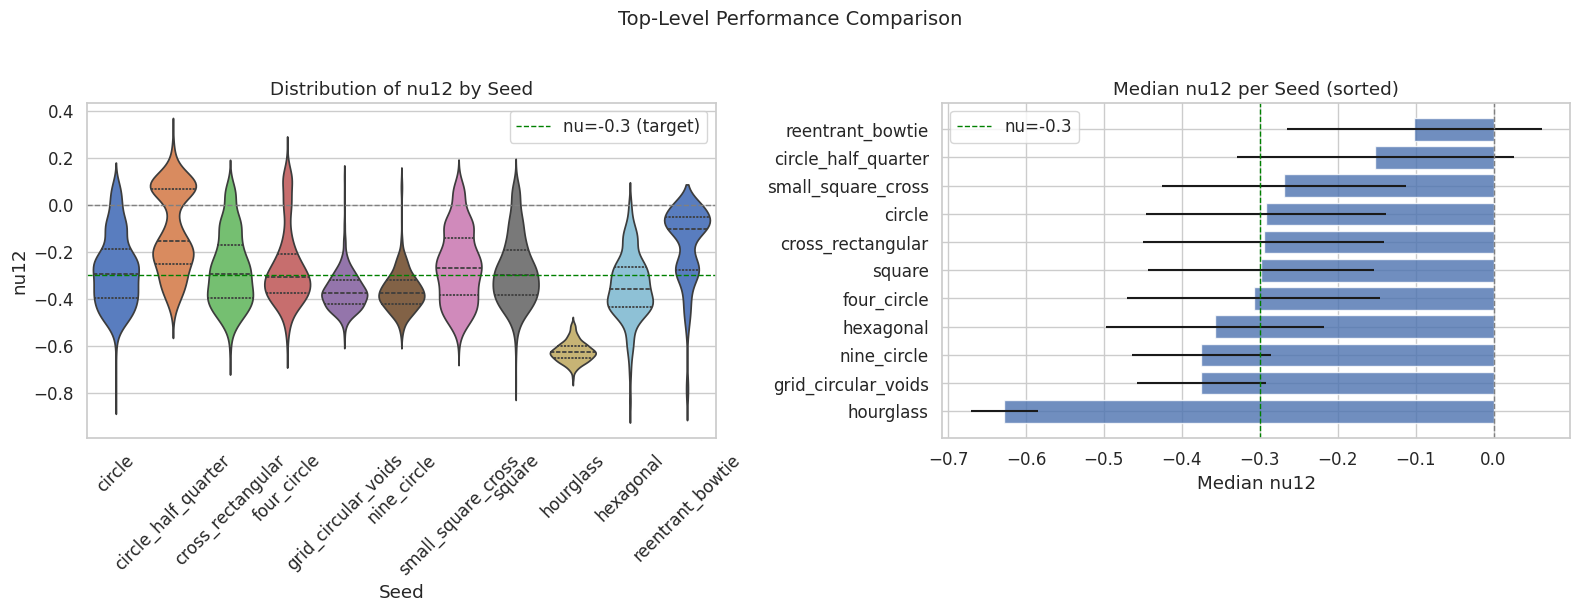


Seed statistics (sorted by median nu12):


,median,mean,std,count
seed,,,,
hourglass,-0.6280,-0.6246,0.0430,720
grid_circular_voids,-0.3752,-0.3654,0.0828,720
nine_circle,-0.3751,-0.3638,0.0894,720
hexagonal,-0.3575,-0.3488,0.1395,720
four_circle,-0.3080,-0.2651,0.1628,719
square,-0.2985,-0.2776,0.1452,719
cross_rectangular,-0.2950,-0.2754,0.1545,719
circle,-0.2924,-0.2775,0.1538,720
small_square_cross,-0.2688,-0.2585,0.1570,720


In [12]:
# ── Violinplot + Boxplot nu12 by seed ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.violinplot(data=df_valid, x="seed", y="final_nu12", ax=ax, palette="muted", inner="quartile")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.axhline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3 (target)")
ax.set_xlabel("Seed")
ax.set_ylabel("nu12")
ax.set_title("Distribution of nu12 by Seed")
ax.tick_params(axis="x", rotation=45)
ax.legend()

ax = axes[1]
seed_stats = df_valid.groupby("seed")["final_nu12"].agg(["median", "mean", "std", "count"]).round(4)
seed_stats_sorted = seed_stats.sort_values("median")
ax.barh(range(len(seed_stats_sorted)), seed_stats_sorted["median"].values, 
        xerr=seed_stats_sorted["std"].values, color="#4c72b0", alpha=0.8)
ax.set_yticks(range(len(seed_stats_sorted)))
ax.set_yticklabels(seed_stats_sorted.index)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.axvline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3")
ax.set_xlabel("Median nu12")
ax.set_title("Median nu12 per Seed (sorted)")
ax.legend()

fig.suptitle("Top-Level Performance Comparison", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Show stats table
print("\nSeed statistics (sorted by median nu12):")
display(seed_stats_sorted)

---
## 8. Heatmap tương quan Spearman

Xác định mối tương quan giữa tất cả tham số và metrics.

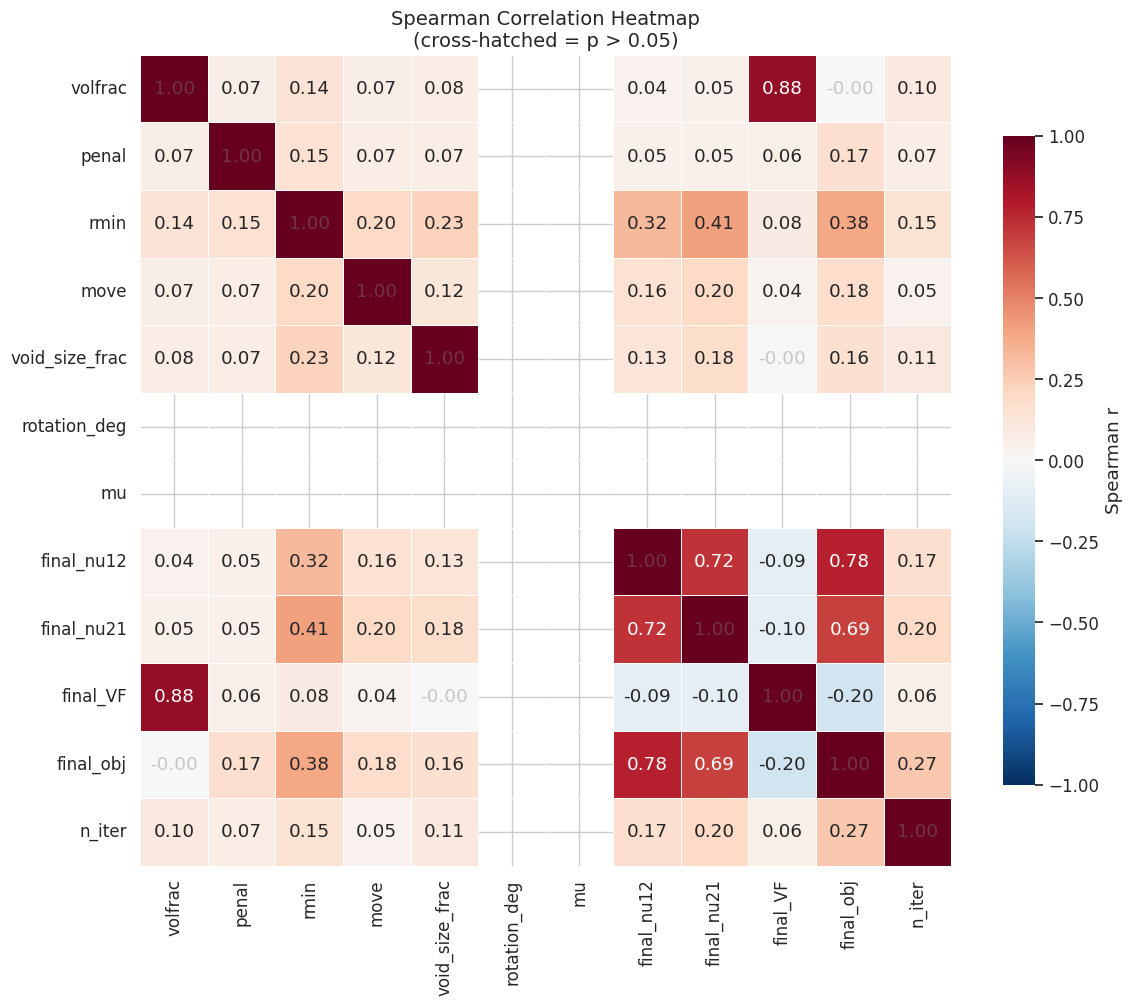


--- Spearman correlation with nu12 ---
  final_VF       : r = -0.0943  (p = 0.0000) ***
  volfrac        : r = +0.0444  (p = 0.0001) ***
  penal          : r = +0.0470  (p = 0.0000) ***
  void_size_frac : r = +0.1250  (p = 0.0000) ***
  move           : r = +0.1559  (p = 0.0000) ***
  n_iter         : r = +0.1668  (p = 0.0000) ***
  rmin           : r = +0.3223  (p = 0.0000) ***
  final_obj      : r = +0.7794  (p = 0.0000) ***
  rotation_deg   : r = +nan  (p = nan) 
  mu             : r = +nan  (p = nan) 


In [13]:
# ── Correlation analysis ──
param_cols = ["volfrac", "penal", "rmin", "move", "void_size_frac", "rotation_deg", "mu"]
metric_cols = ["final_nu12", "final_nu21", "final_VF", "final_obj", "n_iter"]
all_cols = param_cols + metric_cols

df_corr = df_valid[all_cols].dropna()

# Spearman correlation matrix
corr_matrix = df_corr.corr(method="spearman")

# P-value matrix
pval_matrix = pd.DataFrame(np.ones_like(corr_matrix), index=corr_matrix.index, columns=corr_matrix.columns)
for c1 in corr_matrix.columns:
    for c2 in corr_matrix.index:
        if c1 != c2:
            r, p = spearmanr(df_corr[c1], df_corr[c2])
            pval_matrix.loc[c2, c1] = p

# Mask for significance
mask_sig = pval_matrix > 0.05

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            mask=mask_sig, cbar_kws={"shrink": 0.8, "label": "Spearman r"})

# Overlay non-significant cells with hatching
if mask_sig.any().any():
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
                mask=~mask_sig, 
                cbar=False, annot_kws={"color": "gray", "alpha": 0.4})

ax.set_title("Spearman Correlation Heatmap\n(cross-hatched = p > 0.05)", fontsize=14)
fig.tight_layout()
plt.show()

# Print key findings: params vs nu12
print("\n--- Spearman correlation with nu12 ---")
nu_corr = corr_matrix["final_nu12"].drop(["final_nu12", "final_nu21"]).sort_values()
for param, r in nu_corr.items():
    p = pval_matrix.loc[param, "final_nu12"]
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:15s}: r = {r:+.4f}  (p = {p:.4f}) {stars}")

---
## 9. Pareto Front: VolFrac vs nu12

Xác định vùng "vàng" với nu12 < -0.3 đồng thời Volume Fraction hợp lý.

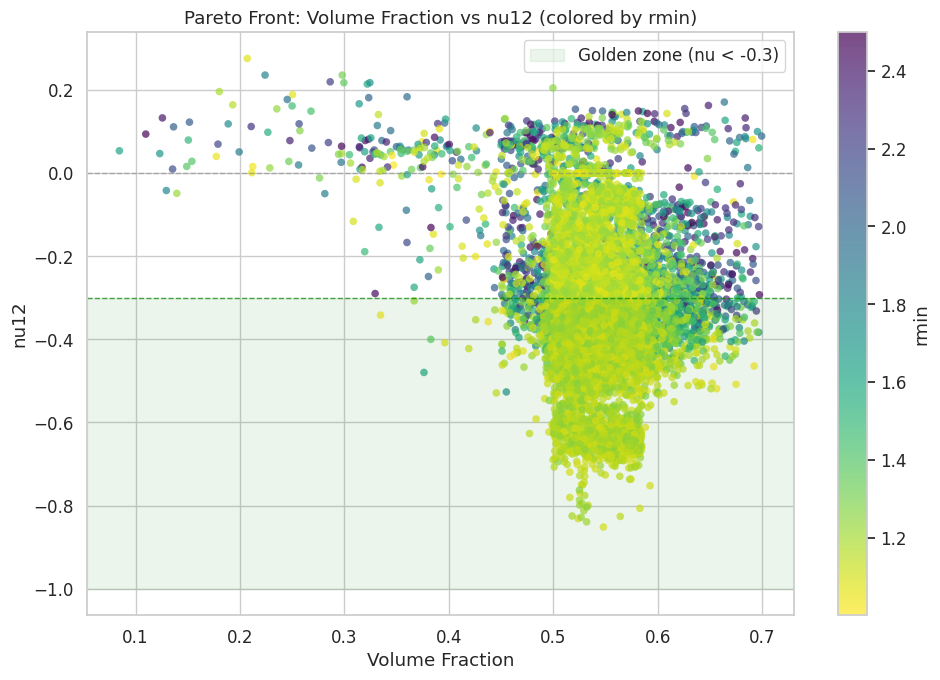

Samples in golden zone (nu12 < -0.3): 4386 (55.4%)
  Their rmin range: 1.00 – 2.49
  Their volfrac range: 0.4508 – 0.6998
  Their void_size_frac range: 0.2500 – 0.5492


In [14]:
# ── Scatter: Volume Fraction vs nu12 ──
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(df_valid["final_VF"], df_valid["final_nu12"], 
                c=df_valid["rmin"], cmap="viridis_r", alpha=0.7, s=30, edgecolors="none")
cbar = plt.colorbar(sc, ax=ax, label="rmin")

# Highlight golden zone
ax.axhspan(-1, -0.3, xmin=0, xmax=1, alpha=0.08, color="green", label="Golden zone (nu < -0.3)")
ax.axhline(-0.3, color="green", ls="--", lw=1, alpha=0.7)
ax.axhline(0, color="gray", ls="--", lw=1, alpha=0.5)

ax.set_xlabel("Volume Fraction")
ax.set_ylabel("nu12")
ax.set_title("Pareto Front: Volume Fraction vs nu12 (colored by rmin)")
ax.legend(loc="upper right")

fig.tight_layout()
plt.show()

# Count golden zone samples
golden = df_valid[df_valid["final_nu12"] < -0.3]
if len(df_valid) > 0:
    golden_pct = len(golden) / len(df_valid) * 100
    print(f"Samples in golden zone (nu12 < -0.3): {len(golden)} ({golden_pct:.1f}%)")
else:
    print(f"Samples in golden zone (nu12 < -0.3): {len(golden)} (0.0%)")
if len(golden) > 0:
    print(f"  Their rmin range: {golden['rmin'].min():.2f} – {golden['rmin'].max():.2f}")
    print(f"  Their volfrac range: {golden['volfrac'].min():.4f} – {golden['volfrac'].max():.4f}")
    print(f"  Their void_size_frac range: {golden['void_size_frac'].min():.4f} – {golden['void_size_frac'].max():.4f}")

---
## 10. Phân tích rmin vs nu12

Tìm ngưỡng rmin tối đa - nếu rmin quá lớn, tính auxetic biến mất.

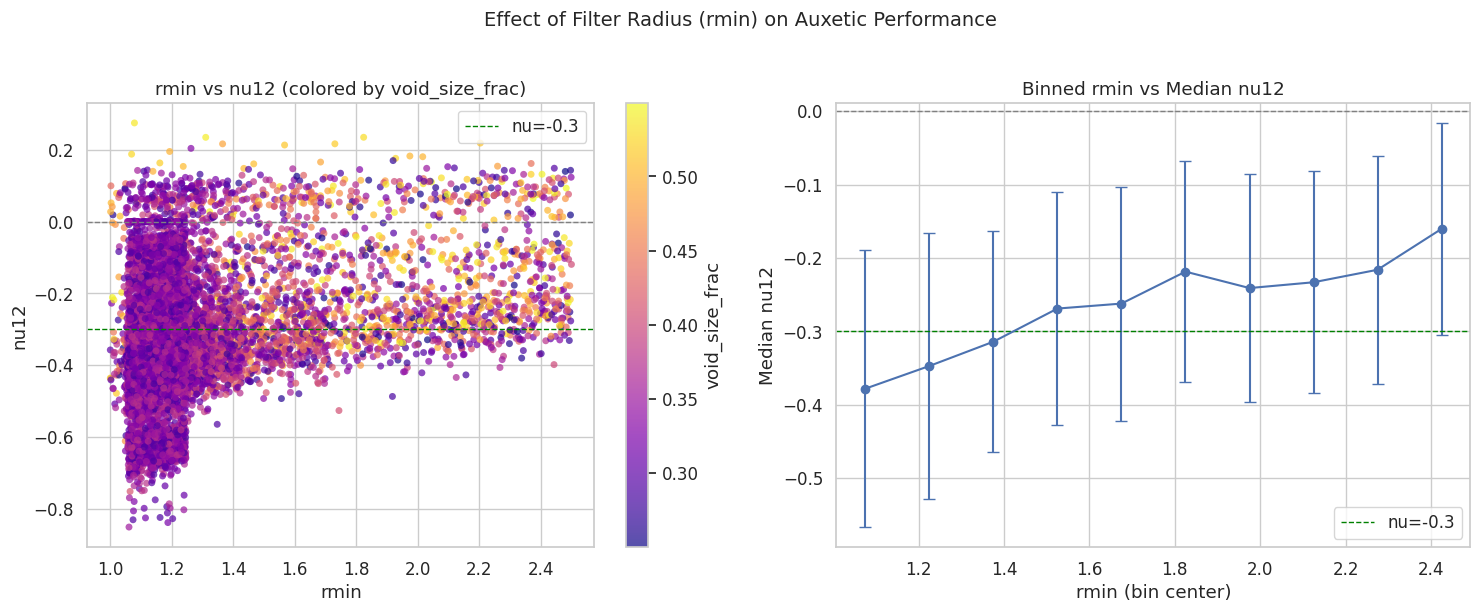

--- rmin Threshold Analysis ---
Samples with rmin > 3: 0
  Among them, auxetic (nu12 < 0): 0 (0.0%)
Max rmin for nu12 < -0.3: 2.49


In [15]:
# ── rmin vs nu12 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.scatter(df_valid["rmin"], df_valid["final_nu12"], 
           c=df_valid["void_size_frac"], cmap="plasma", alpha=0.7, s=25, edgecolors="none")
cbar = plt.colorbar(ax.collections[0], ax=ax, label="void_size_frac")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.axhline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3")
ax.set_xlabel("rmin")
ax.set_ylabel("nu12")
ax.set_title("rmin vs nu12 (colored by void_size_frac)")
ax.legend()

# Determine max rmin threshold
ax = axes[1]
# Bin rmin and compute median nu12 per bin
rmin_bins = pd.cut(df_valid["rmin"], bins=10)
binned = df_valid.groupby(rmin_bins, observed=True)["final_nu12"].agg(["median", "std", "count"])
bin_centers = [interval.mid for interval in binned.index]
ax.errorbar(bin_centers, binned["median"], yerr=binned["std"], 
            marker="o", capsize=4, color="#4c72b0", linestyle="-")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.axhline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3")
ax.set_xlabel("rmin (bin center)")
ax.set_ylabel("Median nu12")
ax.set_title("Binned rmin vs Median nu12")
ax.legend()

fig.suptitle("Effect of Filter Radius (rmin) on Auxetic Performance", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Find threshold
high_rmin = df_valid[df_valid["rmin"] > 3].copy()
auxetic_high_rmin = high_rmin[high_rmin["final_nu12"] < 0]
print(f"--- rmin Threshold Analysis ---")
print(f"Samples with rmin > 3: {len(high_rmin)}")
if len(high_rmin) > 0:
    auxetic_ratio = len(auxetic_high_rmin) / len(high_rmin) * 100
    print(f"  Among them, auxetic (nu12 < 0): {len(auxetic_high_rmin)} ({auxetic_ratio:.1f}%)")
else:
    print("  Among them, auxetic (nu12 < 0): 0 (0.0%)")

# Find max rmin that still produces nu12 < -0.3
if "golden" in locals() and len(golden) > 0:
    golden_rmin_max = golden["rmin"].max()
    print(f"Max rmin for nu12 < -0.3: {golden_rmin_max:.2f}")
else:
    print("Max rmin for nu12 < -0.3: n/a")

---
## 11. Ảnh hưởng của các tham số chính

Phân tích chi tiết `void_size_frac`, `volfrac`, `penal` ảnh hưởng đến nu12.

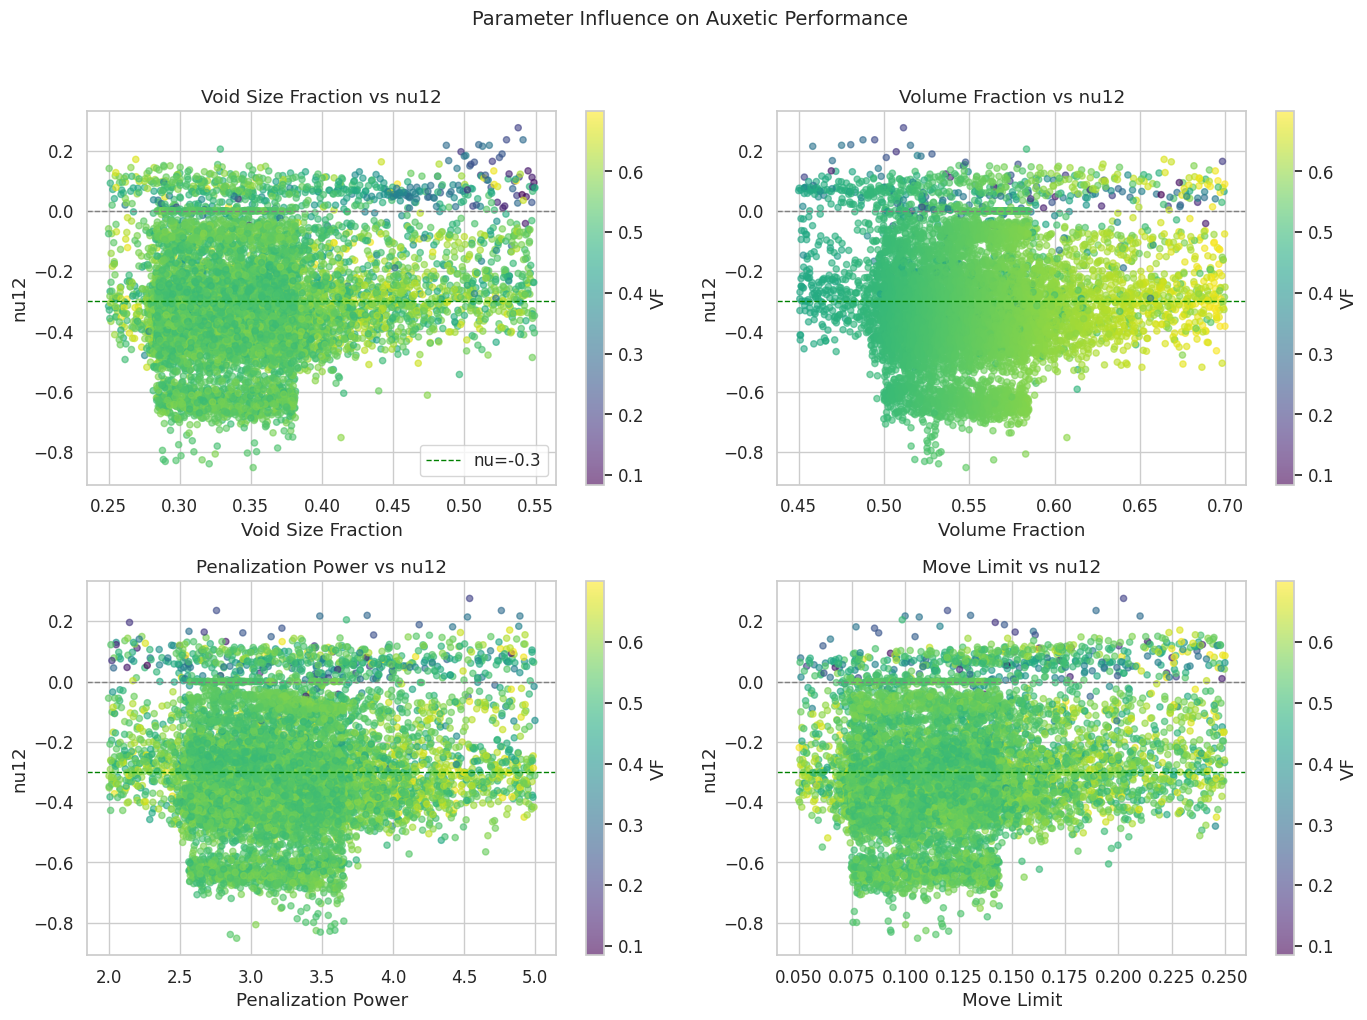

In [16]:
# ── Multi-panel parameter influence ──
key_params = [("void_size_frac", "Void Size Fraction"),
              ("volfrac", "Volume Fraction"),
              ("penal", "Penalization Power"),
              ("move", "Move Limit")]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for i, (param, label) in enumerate(key_params):
    ax = axes_flat[i]
    sc = ax.scatter(df_valid[param], df_valid["final_nu12"],
                    c=df_valid["final_VF"], cmap="viridis", alpha=0.6, s=20)
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.axhline(-0.3, color="green", ls="--", lw=1, label="nu=-0.3")
    ax.set_xlabel(label)
    ax.set_ylabel("nu12")
    ax.set_title(f"{label} vs nu12")
    if i == 0:
        ax.legend()
    plt.colorbar(sc, ax=ax, label="VF")

fig.suptitle("Parameter Influence on Auxetic Performance", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 12. Top 10 thiết kế tốt nhất

Lọc 10 mẫu có `final_nu12` thấp nhất (âm mạnh nhất) và hiển thị ảnh microstructure.

In [17]:
# ── Select top 10 by lowest nu12 ──
top10 = df_valid.nsmallest(10, "final_nu12")[[
    "seed", "sample_id", "sample_path", "final_nu12", "final_nu21", "final_VF",
    "rmin", "volfrac", "void_size_frac", "n_iter"
]].reset_index(drop=True)
top10.index = top10.index + 1  # 1-based ranking

print("Top 10 Auxetic Designs (by lowest nu12)")
print("=" * 90)
display(top10.round(4))

Top 10 Auxetic Designs (by lowest nu12)


,seed,sample_id,sample_path,final_nu12,final_nu21,final_VF,rmin,volfrac,void_size_frac,n_iter
1,hexagonal,1024,outputs/multi_batch/batch_11_dqfix_full_rebuil...,-0.8516,-0.2847,0.5481,1.0613,0.5481,0.3516,150
2,hexagonal,802,outputs/multi_batch/batch_11_dqfix_full_rebuil...,-0.8391,-0.2785,0.5320,1.1877,0.5320,0.3207,150
3,hexagonal,932,outputs/multi_batch/batch_11_dqfix_full_rebuil...,-0.8313,-0.3161,0.5238,1.0744,0.5238,0.2899,150
4,reentrant_bowtie,1977,outputs/multi_batch/batch_11_dqfix_full_rebuil...,-0.8282,-0.4881,0.5268,1.2033,0.5268,0.2974,115
5,hexagonal,747,outputs/multi_batch/batch_11_dqfix_full_rebuil...,-0.8261,-0.4047,0.5643,1.1149,0.5643,0.3158,70
6,hexagonal,1273,outputs/multi_batch/batch_11_dqfix_full_rebuil...,-0.8249,-0.2935,0.5181,1.1623,0.5181,0.2885,150
7,reentrant_bowtie,2067,outputs/multi_batch/batch_11_dqfix_full_rebuil...,-0.8124,-0.5292,0.5294,1.1862,0.5294,0.3009,76
8,circle,89,outputs/multi_batch/batch_8/circle/sample_0089,-0.8066,-0.7792,0.5830,1.0759,0.5830,0.3250,150
9,reentrant_bowtie,2126,outputs/multi_batch/batch_11_dqfix_full_rebuil...,-0.8035,-0.4943,0.5323,1.2397,0.5323,0.3476,147
10,reentrant_bowtie,2061,outputs/multi_batch/batch_11_dqfix_full_rebuil...,-0.7993,-0.5259,0.5335,1.1106,0.5335,0.3100,150


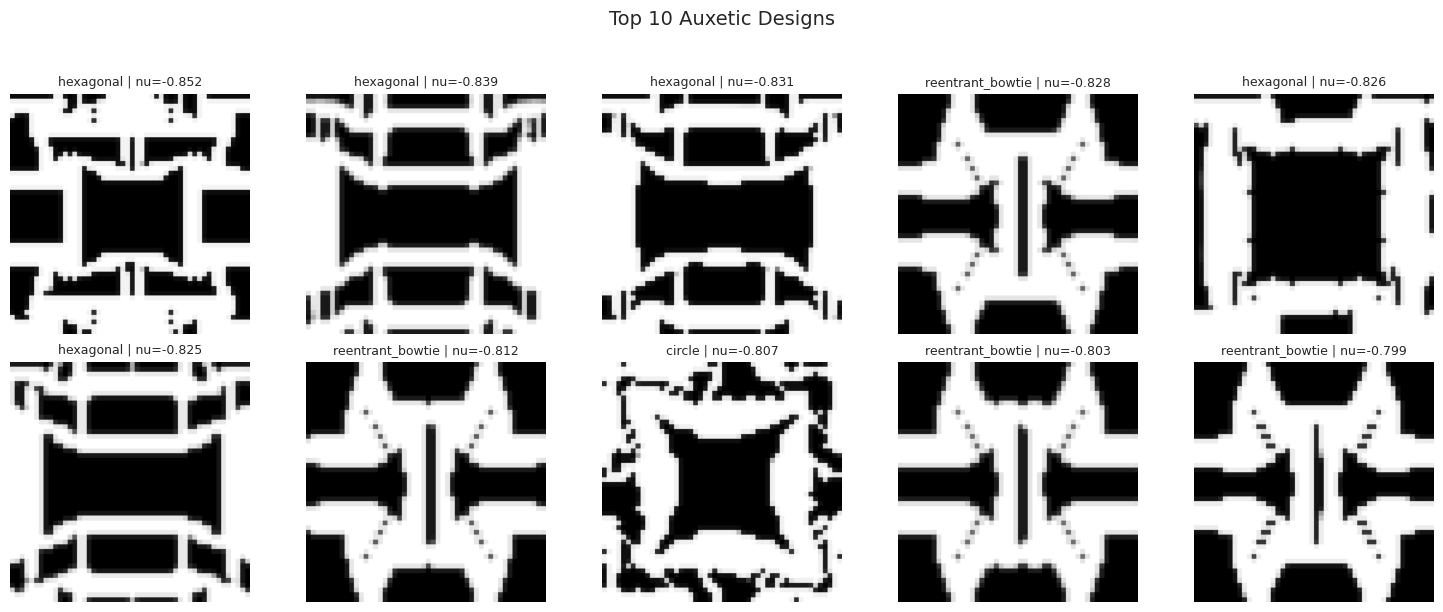

In [18]:
# ── Display top 10 images in a grid ──
fig = utils.plot_top10_grid(top10, figsize=(15, 6))
plt.show()

---
## 13. Convergence History

Chọn 3 mẫu đại diện và vẽ nu12 + Objective theo iteration.

In [19]:
# ── Select representative samples ──
# Good: top 1
# Medium: sample with nu12 around -0.1
# Failed: sample with nu12 > 0 (worst among valid)

good_sample = df_valid.nsmallest(1, "final_nu12").iloc[0]
failed_sample = df_valid[df_valid["final_nu12"] >= 0].nsmallest(1, "final_nu12").iloc[0] \
    if (df_valid["final_nu12"] >= 0).any() else df_valid.nlargest(1, "final_nu12").iloc[0]

# Find a sample with nu12 around -0.1
target_nu = -0.1
medium_idx = (df_valid["final_nu12"] - target_nu).abs().idxmin()
if medium_idx == good_sample.name or medium_idx == failed_sample.name:
    # Fallback: pick the median sample
    medium_nu = df_valid["final_nu12"].median()
    medium_idx = (df_valid["final_nu12"] - medium_nu).abs().idxmin()
medium_sample = df_valid.loc[medium_idx]

representatives = [
    ("✅ Excellent", good_sample),
    ("➖ Moderate", medium_sample),
    ("❌ Failed", failed_sample),
]

print("Representative samples for convergence analysis:")
for label, s in representatives:
    print(f"  {label}: seed={s['seed']}, sample={s['sample_id']}, nu12={s['final_nu12']:.4f}")

Representative samples for convergence analysis:
  ✅ Excellent: seed=hexagonal, sample=1024, nu12=-0.8516
  ➖ Moderate: seed=cross_rectangular, sample=243, nu12=-0.1003
  ❌ Failed: seed=reentrant_bowtie, sample=1633, nu12=0.0000


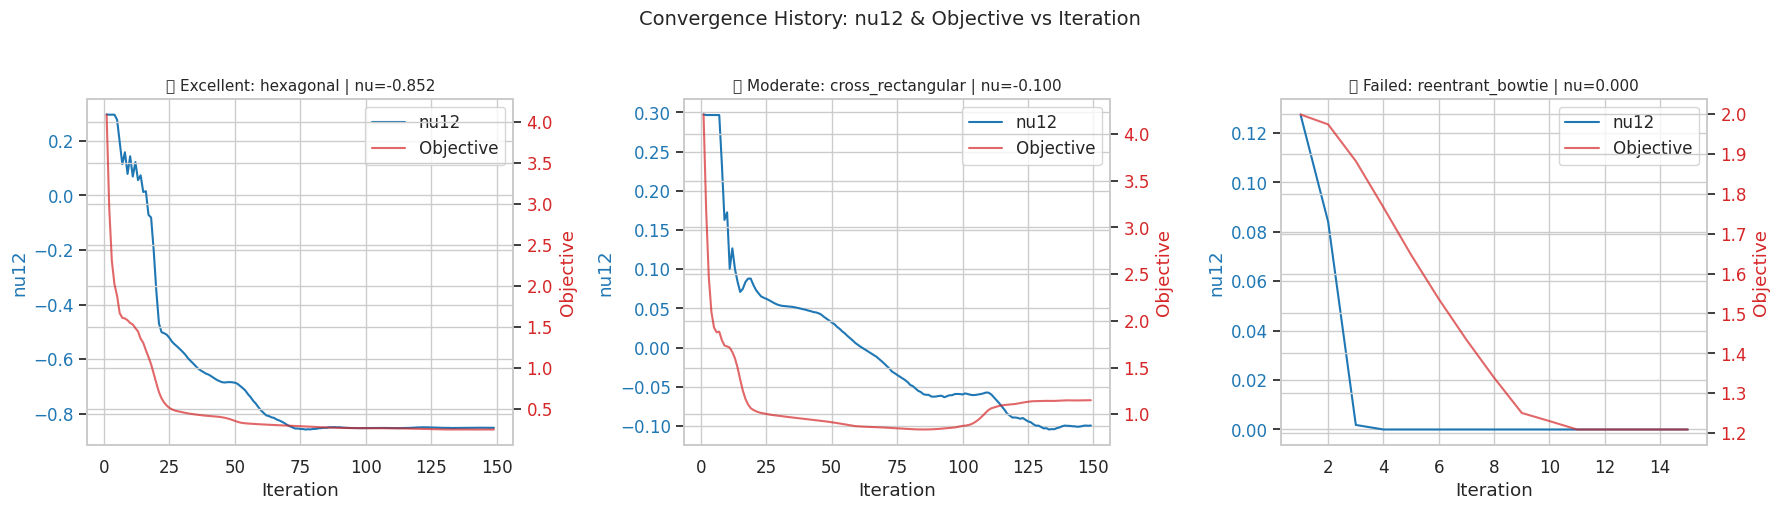

In [20]:
# ── Plot convergence histories ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (label, s) in enumerate(representatives):
    ax = axes[i]
    csv_path = utils.resolve_repo_path(s["sample_path"]) / "iteration_data.csv"
    hist = utils.load_sample_history(csv_path)
    if hist is not None and len(hist) > 1:
        utils.plot_convergence(ax, hist, label_prefix="",
                               color_nu="#1f77b4", color_obj="#d62728")
        ax.set_title(f"{label}: {s['seed']} | nu={s['final_nu12']:.3f}", fontsize=11)
    else:
        ax.text(0.5, 0.5, "No history data", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)

fig.suptitle("Convergence History: nu12 & Objective vs Iteration", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

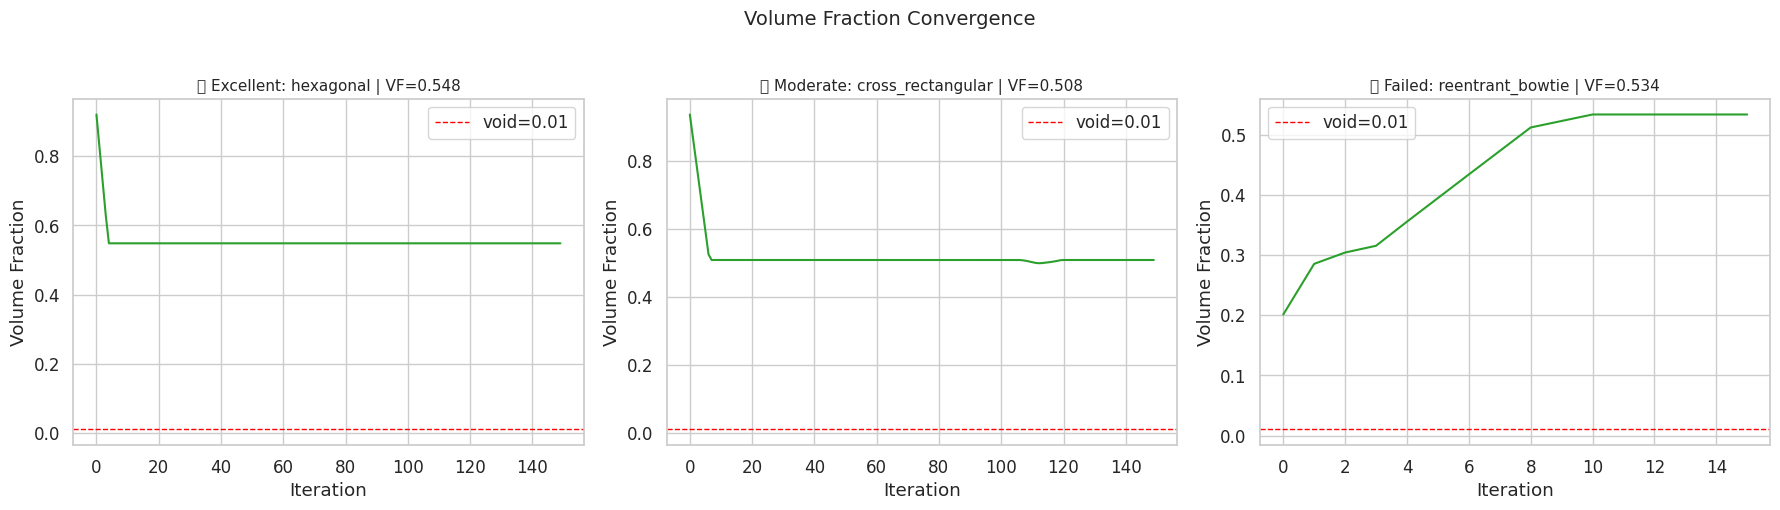

In [21]:
# ── Additional: Volume Fraction convergence ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (label, s) in enumerate(representatives):
    ax = axes[i]
    csv_path = utils.resolve_repo_path(s["sample_path"]) / "iteration_data.csv"
    hist = utils.load_sample_history(csv_path)
    if hist is not None and len(hist) > 1:
        ax.plot(hist["Iteration"], hist["Volume_Fraction"], color="#2ca02c", lw=1.5)
        ax.axhline(utils.VOID_THRESHOLD, color="red", ls="--", lw=1, label=f"void={utils.VOID_THRESHOLD}")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Volume Fraction")
        ax.set_title(f"{label}: {s['seed']} | VF={s['final_VF']:.3f}", fontsize=11)
        ax.legend()
    else:
        ax.text(0.5, 0.5, "No history data", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)

fig.suptitle("Volume Fraction Convergence", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 14. Kiểm tra Rotation

Kiểm tra xem các thiết kế có bị ảnh hưởng bởi rotation không (coupling shear-normal).

> **Lưu ý:** `iteration_data.csv` không trực tiếp chứa tensor Q. Tuy nhiên, metadata chứa tham số `rotation_deg`. Nếu rotation_deg != 0, coupling có thể xảy ra. Chúng ta kiểm tra mối tương quan giữa `rotation_deg` và `final_nu12`.

In [22]:
# ── Rotation analysis ──
# Check if rotation_deg correlates with nu12
rotation_ids = df_valid["rotation_deg"].dropna()
n_with_rotation = (rotation_ids != 0).sum()
n_without_rotation = (rotation_ids == 0).sum()

print(f"--- Rotation Distribution ---")
print(f"Samples WITHOUT rotation (rotation_deg=0): {n_without_rotation}")
print(f"Samples WITH rotation (rotation_deg!=0):  {n_with_rotation}")

# Compare nu12 distributions
if n_with_rotation > 5 and n_without_rotation > 5:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    df_rot = df_valid[df_valid["rotation_deg"] != 0]
    df_norot = df_valid[df_valid["rotation_deg"] == 0]
    
    ax.hist(df_norot["final_nu12"].dropna(), bins=25, alpha=0.7, label=f"No rotation (n={len(df_norot)})",
            color="#4c72b0", edgecolor="white")
    ax.hist(df_rot["final_nu12"].dropna(), bins=25, alpha=0.7, label=f"With rotation (n={len(df_rot)})",
            color="#c44e52", edgecolor="white")
    ax.set_xlabel("nu12")
    ax.set_ylabel("Count")
    ax.set_title("nu12 Distribution: Rotation vs No Rotation")
    ax.legend()
    
    ax = axes[1]
    sc = ax.scatter(df_valid["rotation_deg"], df_valid["final_nu12"],
                    c=df_valid["final_VF"], cmap="viridis", alpha=0.7, s=25)
    plt.colorbar(sc, ax=ax, label="VF")
    ax.set_xlabel("Rotation (degrees)")
    ax.set_ylabel("nu12")
    ax.set_title("nu12 vs Rotation (colored by Volume Fraction)")
    
    fig.suptitle("Rotation Effect on Auxetic Performance", fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()
    
    # Spearman
    r_rot, p_rot = utils.safe_spearman(df_valid, "rotation_deg", "final_nu12")
    print(f"\nSpearman correlation rotation vs nu12: r = {r_rot:.4f}, p = {p_rot:.4f}")
else:
    print("\nInsufficient rotation samples for comparison.")

--- Rotation Distribution ---
Samples WITHOUT rotation (rotation_deg=0): 7917
Samples WITH rotation (rotation_deg!=0):  0

Insufficient rotation samples for comparison.


**Kết luận về Rotation:**
- Nếu rotation_deg có tương quan đáng kể với nu12: cần giới hạn hoặc kiểm soát rotation trong Phase 2.
- Nếu rotation_deg không ảnh hưởng: rotation có thể được fixed = 0 để giảm không gian tham số.

---
## Tổng kết


In [23]:
# ── Tổng kết ──
top3_seeds = seed_stats_sorted.head(3).index.tolist()
# Tham số ảnh hưởng mạnh nhất = |tương quan Spearman với ν12| lớn nhất (§8).
# Chỉ xếp hạng trong param_cols: nu_corr còn chứa metric đầu ra (final_obj,
# n_iter...) - chúng tương quan với ν12 nhưng không phải tham số điều khiển.
param_influence = nu_corr[param_cols].abs().sort_values(ascending=False)

print("=" * 60)
print("  DATASET DOE - TỔNG KẾT")
print("=" * 60)
print("[A] Chất lượng dữ liệu")
print(f"  • Total samples scanned:        {len(df_raw)}")
print(f"  • Seeds covered:                {df_raw['seed'].nunique()}")
print(f"  • Converged early (tolerance):  {converged_rate:.1f}%")
if "disconnected_flag" in df_raw.columns:
    print(f"  • Disconnected geometry:        {disc_rate:.1f}%")
print(f"  • Void collapse rate:           {df_raw['void_flag'].mean()*100:.1f}%")
print(f"  • nu12 valid rate:              {valid/total*100:.1f}%")
print(f"  • Valid & non-void samples:     {len(df_valid)}")
print("[B] Hiệu năng & độ nhạy")
print(f"  • Top 3 seeds (median nu12):    {', '.join(top3_seeds)}")
print(f"  • Samples with nu12 < -0.3:     {len(golden)}")
print(f"  • Samples with nu12 < -0.5:     {(df_valid['final_nu12'] < -0.5).sum()}")
print(f"  • Max rmin for nu12 < -0.3:     {golden_rmin_max:.2f}")
print("  • Most influential parameters on nu12:")
for param in param_influence.head(3).index:
    print(f"      {param:20s}: r = {nu_corr[param]:+.4f}")
print("=" * 60)


  DATASET DOE - TỔNG KẾT
[A] Chất lượng dữ liệu
  • Total samples scanned:        7920
  • Seeds covered:                11
  • Converged early (tolerance):  23.7%
  • Disconnected geometry:        23.9%
  • Void collapse rate:           0.0%
  • nu12 valid rate:              100.0%
  • Valid & non-void samples:     7917
[B] Hiệu năng & độ nhạy
  • Top 3 seeds (median nu12):    hourglass, grid_circular_voids, nine_circle
  • Samples with nu12 < -0.3:     4386
  • Samples with nu12 < -0.5:     956
  • Max rmin for nu12 < -0.3:     2.49
  • Most influential parameters on nu12:
      rmin                : r = +0.3223
      move                : r = +0.1559
      void_size_frac      : r = +0.1250
